In [2]:
import os,random,glob,zipfile
import numpy as np
import librosa,soundfile as sf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader




In [3]:
#PARAMETERS
SR=16000
DURATION=5.0
TARGET_LEN=int(SR*DURATION)
N_FFT=512
HOP_LENGTH=256
BATCH_SIZE=8
NUM_EPOCHS=50
LR=5e-5
WEIGHT_DECAY=1e-5
PATIENCE=10
USE_AMP=True
def unzip_all(zip_folder, extract_to):
    for file in os.listdir(zip_folder):
        if file.endswith(".zip"):
            path = os.path.join(zip_folder, file)
            print("Extracting:", file)
            with zipfile.ZipFile(path, 'r') as z:
                z.extractall(extract_to)
unzip_all(r"C:\Users\JOSHITAA\Documents\404FunNotFound\AI-Voice-Enhancer\data\noisy datset", r"C:\Users\JOSHITAA\Documents\404FunNotFound\AI-Voice-Enhancer\data\noisy datset")
CLEAN_DATASET_DIR = r"C:\Users\JOSHITAA\Documents\404FunNotFound\AI-Voice-Enhancer\data\clean datset"
NOISE_DATASET_DIR = r"C:\Users\JOSHITAA\Documents\404FunNotFound\AI-Voice-Enhancer\data\noisy datset"
mic_inner = os.path.join(CLEAN_DATASET_DIR, "MIC")
CLEAN_ROOT = mic_inner if os.path.exists(mic_inner) else CLEAN_DATASET_DIR
speaker_folders=sorted([
    d for d in os.listdir(CLEAN_ROOT)
    if os.path.isdir(os.path.join(CLEAN_ROOT, d))
])
print("Speakers found:", speaker_folders)
random.seed(42)
random.shuffle(speaker_folders)
split=int(0.8*len(speaker_folders))
train_speakers=speaker_folders[:split]
val_speakers=speaker_folders[split:]

train_clean_files,val_clean_files=[],[]
for spk in speaker_folders:
    path=os.path.join(CLEAN_ROOT,spk)
    wavs=sorted(glob.glob(os.path.join(path,"*.wav")))
    if spk in train_speakers:
        train_clean_files.extend(wavs)
    else:
        val_clean_files.extend(wavs)
noise_files = sorted(
    glob.glob(os.path.join(NOISE_DATASET_DIR, "**", "*.wav"), recursive=True)
)
assert len(train_clean_files)>0, "No training clean files found"
assert len(val_clean_files)>0, "validation clean set is empty"
assert len(noise_files)>0, "No noise files found"
print("Noise files found:", len(noise_files))
print("Example noise file:", noise_files[:5])

Extracting: DKITCHEN_16k.zip
Extracting: DLIVING_16k.zip
Extracting: DWASHING_16k.zip
Extracting: NFIELD_16k.zip
Extracting: NPARK_16k.zip
Extracting: NRIVER_16k.zip
Extracting: OHALLWAY_16k.zip
Extracting: OMEETING_16k.zip
Extracting: PRESTO_16k.zip
Extracting: PSTATION_16k.zip
Speakers found: ['F01', 'F02', 'M01', 'M02']
Noise files found: 160
Example noise file: ['C:\\Users\\JOSHITAA\\Documents\\404FunNotFound\\AI-Voice-Enhancer\\data\\noisy datset\\DKITCHEN\\ch01.wav', 'C:\\Users\\JOSHITAA\\Documents\\404FunNotFound\\AI-Voice-Enhancer\\data\\noisy datset\\DKITCHEN\\ch02.wav', 'C:\\Users\\JOSHITAA\\Documents\\404FunNotFound\\AI-Voice-Enhancer\\data\\noisy datset\\DKITCHEN\\ch03.wav', 'C:\\Users\\JOSHITAA\\Documents\\404FunNotFound\\AI-Voice-Enhancer\\data\\noisy datset\\DKITCHEN\\ch04.wav', 'C:\\Users\\JOSHITAA\\Documents\\404FunNotFound\\AI-Voice-Enhancer\\data\\noisy datset\\DKITCHEN\\ch05.wav']


In [4]:
#MIXING FUNCTION
def mix_with_random_noise(clean, noise_files,sr=SR,target_len=TARGET_LEN):
    clean=librosa.util.fix_length(clean,size=target_len)

    noise_path=random.choice(noise_files)
    noise,_=librosa.load(noise_path,sr=sr)

    if len(noise)>target_len:
        start=random.randint(0,len(noise)-target_len)
        noise=noise[start:start+target_len]
    else:
        noise=np.pad(noise,(0,target_len-len(noise)))

    if random.random()<0.25:
        try:
            speed = random.uniform(0.9, 1.1)
            noise = librosa.effects.time_stretch(noise, rate=speed)
            noise = librosa.util.fix_length(noise, size=target_len)
        except Exception:
            pass


    snr_db = random.uniform(0, 20)
    rms_clean = np.sqrt(np.mean(clean**2) + 1e-12)
    rms_noise = np.sqrt(np.mean(noise**2) + 1e-12)
    desired_rms_noise = rms_clean / (10 ** (snr_db / 20))
    noise = noise * (desired_rms_noise / (rms_noise + 1e-12))
    noise = noise * random.uniform(0.7, 1.2)

    mixed = clean + noise

    maxv = np.max(np.abs(mixed)) + 1e-12
    if maxv > 1.0:
        mixed = mixed / maxv
    return mixed.astype(np.float32), clean.astype(np.float32)

In [5]:
#DATASET
class SpeechMaskDataset(Dataset):
    def __init__(self,clean_files,noise_files,sr=SR,n_fft=N_FFT,hop_length=HOP_LENGTH,augment=True):
        self.clean_files=clean_files
        self.noise_files=noise_files
        self.sr=sr
        self.n_fft=n_fft
        self.hop_length=hop_length
        self.augment=augment

    def __len__(self):
        return len(self.clean_files)
    def __getitem__(self,idx):
        clean_wav, _=librosa.load(self.clean_files[idx],sr=self.sr)
        mixed_wav,clean_wav=mix_with_random_noise(clean_wav,self.noise_files,sr=self.sr)

        noisy_stft=librosa.stft(mixed_wav,n_fft=self.n_fft,hop_length=self.hop_length)
        clean_stft=librosa.stft(clean_wav,n_fft=self.n_fft,hop_length=self.hop_length)

        noisy_mag=np.abs(noisy_stft)
        clean_mag=np.abs(clean_stft)

        mask=clean_mag/(noisy_mag+1e-8)
        mask=np.clip(mask,0.0,1.0)

        noisy_mag=np.log1p(noisy_mag)
        noisy_mag_norm=noisy_mag/(noisy_mag.max()+1e-8)

        noisy_tensor=torch.tensor(noisy_mag_norm, dtype=torch.float32).unsqueeze(0)
        mask_tensor=torch.tensor(mask,dtype=torch.float32).unsqueeze(0)

        return noisy_tensor,mask_tensor,mixed_wav.astype(np.float32), clean_wav.astype(np.float32)
train_dataset=SpeechMaskDataset(train_clean_files,noise_files)
val_dataset=SpeechMaskDataset(val_clean_files,noise_files)

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True, drop_last=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False, drop_last=False)
print(f"Data ready | Train: {len(train_dataset)} | Val: {len(val_dataset)}")


Data ready | Train: 708 | Val: 236


In [6]:
#MODEL
class UNetMask(nn.Module):
    def __init__(self):
        super().__init__()
        def down(in_ch,out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch,out_ch,3,2,1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        def up(in_ch,out_ch):
            return nn.Sequential(
                nn.ConvTranspose2d(in_ch,out_ch,4,2,1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        self.enc1=down(1,16)
        self.enc2=down(16,32)
        self.enc3=down(32,64)
        self.enc4=down(64,128)

        self.dec1=up(128,64)
        self.dec2=up(128,32)
        self.dec3=up(64,16)

        self.out_conv=nn.Conv2d(32,1,3,1,1)
        self.out_activation=nn.Sigmoid()

    def forward(self,x):
        e1=self.enc1(x)
        e2=self.enc2(e1)
        e3=self.enc3(e2)
        e4=self.enc4(e3)

        d1=self.dec1(e4)
        e3a=F.interpolate(e3,size=d1.size()[2:],mode="bilinear",align_corners=False)
        d1=torch.cat([d1,e3a],dim=1)

        d2=self.dec2(d1)
        e2a=F.interpolate(e2,size=d2.size()[2:],mode="bilinear",align_corners=False)
        d2=torch.cat([d2,e2a],dim=1)

        d3=self.dec3(d2)
        e1a=F.interpolate(e1,size=d3.size()[2:],mode="bilinear",align_corners=False)
        d3=torch.cat([d3,e1a],dim=1)

        out=self.out_conv(d3)
        out=self.out_activation(out)
        out=F.interpolate(out,size=x.shape[2:],mode="bilinear",align_corners=False)
        return out

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=UNetMask().to(device)
print("Model ready on",device)


Model ready on cpu


In [7]:
#METRICS(measures how much our model improves the audio quality using SNR)
def compute_snr(clean,test):
    clean=np.asarray(clean,dtype=np.float64)
    test=np.asarray(test,dtype=np.float64)

    min_len=min(len(clean),len(test))
    clean=clean[:min_len]
    test=test[:min_len]

    noise=clean-test
    signal_power=np.sum(clean**2)+1e-12
    noise_power=np.sum(noise**2)+1e-12

    return 10*np.log10(signal_power/noise_power)

def evaluate_snr(clean,noisy,enhanced):
    snr_noisy=compute_snr(clean,noisy)
    snr_enh=compute_snr(clean,enhanced)
    delta_snr=snr_enh-snr_noisy

    return snr_noisy,snr_enh,delta_snr

In [8]:
#TRAINING
mse=nn.MSELoss()
l1=nn.L1Loss()

optimizer=optim.Adam(model.parameters(),lr=LR, weight_decay=WEIGHT_DECAY)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',patience=3)
scaler=torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type=="cuda"))

train_losses,val_losses=[],[]
best_val=float('inf')
patience_cnt=0

print("\nStarting training...\n")
for epoch in range (NUM_EPOCHS):
    model.train()
    total_train_loss=0.0

    for noisy,mask, _, _ in train_loader:
        noisy=noisy.to(device)
        mask=mask.to(device)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type=="cuda")):
            pred=model(noisy)
            loss=0.7*mse(pred,mask)+0.3*l1(pred,mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss+=loss.item()
    avg_train_loss=total_train_loss/len(train_loader)

    model.eval()
    total_val_loss=0.0

    with torch.no_grad():
        for noisy,mask, _, _ in val_loader:
            noisy=noisy.to(device)
            mask=mask.to(device)

            with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type=="cuda")):
                pred=model(noisy)
                val_loss=0.7*mse(pred,mask)+0.3*l1(pred,mask)

            total_val_loss+=val_loss.item()

    avg_val_loss=total_val_loss/len(val_loader)
    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1:03}/{NUM_EPOCHS} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

    if avg_val_loss < best_val:
        best_val=avg_val_loss
        torch.save(model.state_dict(),"best_mask_unet.pth")
        print("Best model saved")
        patience_cnt=0

    else:
        patience_cnt+=1
        if patience_cnt>=PATIENCE:
            print("early stopping triggered")
            break
print("\nTraining finished")


C:\Users\JOSHITAA\AppData\Local\Temp\ipykernel_25616\4182458642.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type=="cuda"))



Starting training...



C:\Users\JOSHITAA\AppData\Local\Temp\ipykernel_25616\4182458642.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type=="cuda")):
C:\Users\JOSHITAA\AppData\Local\Temp\ipykernel_25616\4182458642.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device.type=="cuda")):


Epoch 001/50 | Train: 0.2026 | Val: 0.1626
Best model saved
Epoch 002/50 | Train: 0.1491 | Val: 0.1285
Best model saved
Epoch 003/50 | Train: 0.1311 | Val: 0.1169
Best model saved
Epoch 004/50 | Train: 0.1208 | Val: 0.1189
Epoch 005/50 | Train: 0.1171 | Val: 0.1057
Best model saved
Epoch 006/50 | Train: 0.1159 | Val: 0.1062
Epoch 007/50 | Train: 0.1125 | Val: 0.1070
Epoch 008/50 | Train: 0.1131 | Val: 0.1003
Best model saved
Epoch 009/50 | Train: 0.1121 | Val: 0.0995
Best model saved
Epoch 010/50 | Train: 0.1092 | Val: 0.1166
Epoch 011/50 | Train: 0.1083 | Val: 0.1002
Epoch 012/50 | Train: 0.1083 | Val: 0.0992
Best model saved
Epoch 013/50 | Train: 0.1088 | Val: 0.1068
Epoch 014/50 | Train: 0.1070 | Val: 0.0982
Best model saved
Epoch 015/50 | Train: 0.1060 | Val: 0.1026
Epoch 016/50 | Train: 0.1075 | Val: 0.0969
Best model saved
Epoch 017/50 | Train: 0.1037 | Val: 0.1104
Epoch 018/50 | Train: 0.1042 | Val: 0.1007
Epoch 019/50 | Train: 0.1055 | Val: 0.0973
Epoch 020/50 | Train: 0.1034 |

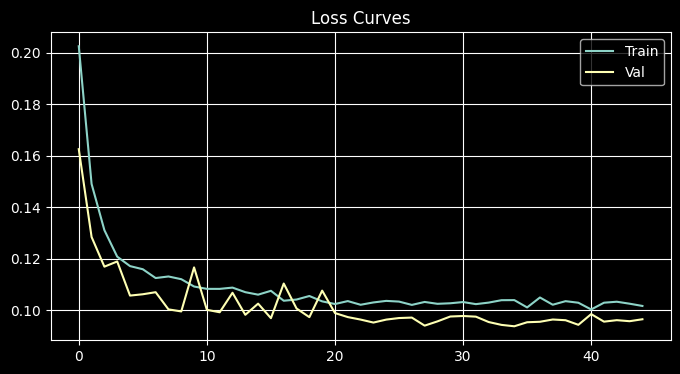

Evaluation Metrics
Noisy SNR: 15.57 dB
Enhanced SNR: 23.61 dB
ΔSNR (Gain): 8.04 dB


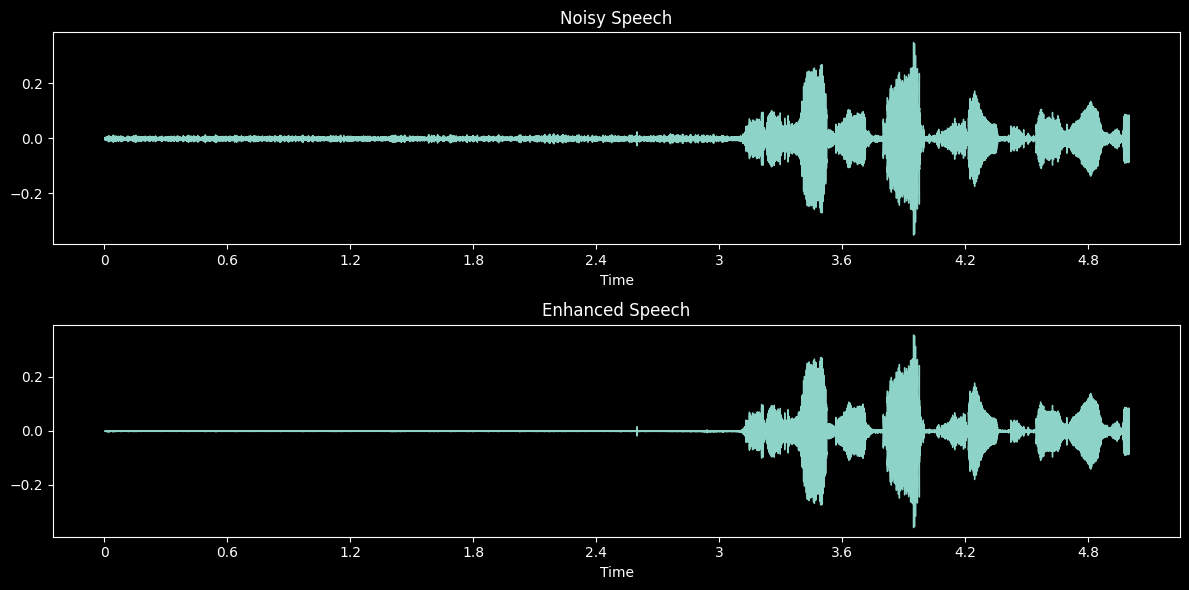

In [9]:
#LOSS CURVE
plt.figure(figsize=(8,4))
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Val")
plt.legend(); plt.grid();plt.title("Loss Curves")
plt.show()

#VISUALIZE
os.makedirs("samples", exist_ok=True)
os.makedirs("results",exist_ok=True)

import librosa.display
model.load_state_dict(torch.load("best_mask_unet.pth", map_location=device))
model.eval()

noisy_tensor, target_mask_tensor, mixed_wave, clean_wave=val_dataset[0]
clean_wave=librosa.util.fix_length(clean_wave,size=len(mixed_wave))
noisy_np=noisy_tensor.squeeze().numpy()
target_mask_np=target_mask_tensor.squeeze().numpy()

with torch.no_grad():
    pred_mask=model(noisy_tensor.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()
pred_mask=pred_mask.squeeze(0)

noisy_stft=librosa.stft(mixed_wave,n_fft=N_FFT,hop_length=HOP_LENGTH)
noisy_mag=np.abs(noisy_stft)
noisy_phase=np.angle(noisy_stft)

F_o, T_o=noisy_mag.shape
F_p, T_p=pred_mask.shape
if F_p!=F_o or T_p!=T_o:
    pred_mask=np.pad(pred_mask,((0,max(0,F_o-F_p)),(0,max(0,T_o-T_p))),mode="constant")
    pred_mask=pred_mask[:F_o, :T_o]
pred_mask=np.clip(pred_mask,0.0,1.0)
enhanced_mag=pred_mask*np.abs(noisy_stft)

enh_stft=enhanced_mag*np.exp(1j*noisy_phase)
enh_audio=librosa.istft(enh_stft,hop_length=HOP_LENGTH,length=len(mixed_wave))

def rms(x):return np.sqrt(np.mean(x**2)+1e-12)
r_orig=rms(mixed_wave)
r_enh=rms(enh_audio)

if r_enh>0:
    enh_audio=enh_audio*(r_orig/r_enh)
enh_audio=np.clip(enh_audio,-0.99,0.99)
snr_noisy,snr_enh,delta_snr=evaluate_snr(clean_wave,mixed_wave,enh_audio)

print("Evaluation Metrics")
print(f"Noisy SNR: {snr_noisy:.2f} dB")
print(f"Enhanced SNR: {snr_enh:.2f} dB")
print(f"ΔSNR (Gain): {delta_snr:.2f} dB")

sf.write("samples/noisy.wav",mixed_wave.astype(np.float32),SR)
sf.write("samples/enhanced.wav",enh_audio.astype(np.float32),SR)

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
librosa.display.waveshow(mixed_wave, sr=SR)
plt.title("Noisy Speech")

plt.subplot(2,1,2)
librosa.display.waveshow(enh_audio, sr=SR)
plt.title("Enhanced Speech")

plt.tight_layout()
plt.savefig("results/waveform_comparison.png", dpi=200)
plt.show()


Selected file: C:/Users/JOSHITAA/Documents/404FunNotFound/audio files/sample.wav
Enhanced file saved at: C:\Users\JOSHITAA\Documents\404FunNotFound\AI-Voice-Enhancer/enhanced_audio.wav


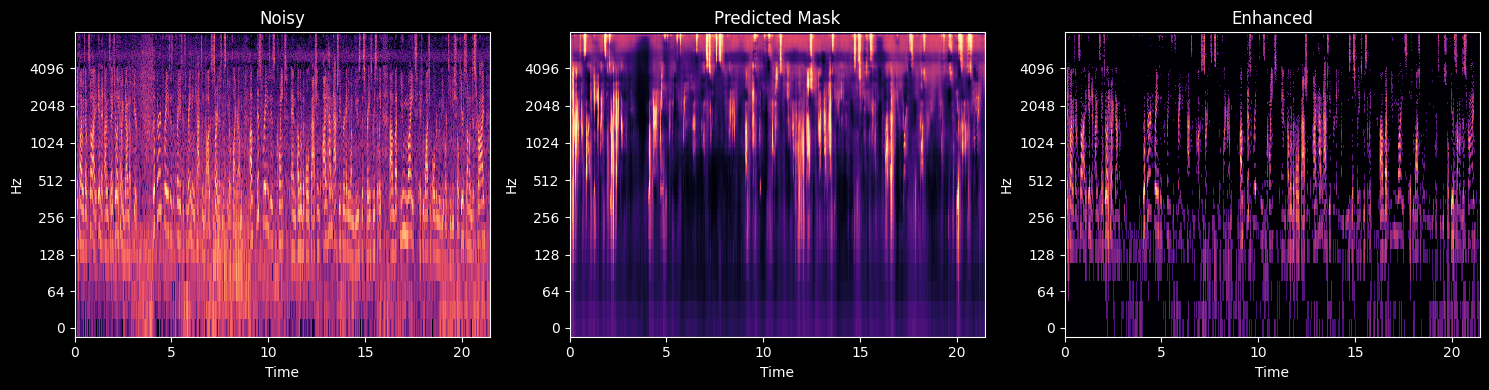

In [13]:
import librosa.display
from tkinter import Tk
from tkinter.filedialog import askopenfilename

SR = 16000
N_FFT = 512
HOP_LENGTH = 128

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs("results", exist_ok=True)

model = UNetMask().to(DEVICE)
model.load_state_dict(torch.load("best_mask_unet.pth", map_location=DEVICE))
model.eval()

Tk().withdraw()

audio_path = askopenfilename(
    title="Select an audio file",
    filetypes=[("Audio Files", "*.wav *.mp3 *.flac")]
)

print("Selected file:", audio_path)

wave, sr = librosa.load(audio_path, sr=SR)

stft = librosa.stft(wave, n_fft=N_FFT, hop_length=HOP_LENGTH)
mag, phase = np.abs(stft), np.angle(stft)

mag_norm = mag / (np.max(mag) + 1e-12)

mag_tensor = torch.tensor(mag_norm).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

with torch.no_grad():
    pred_mask = model(mag_tensor).squeeze().cpu().numpy()

gamma = 1.5

enhanced_mag = mag * (pred_mask ** gamma)

noise_floor = 0.001 * np.max(enhanced_mag)
enhanced_mag[enhanced_mag < noise_floor] = 0.0

frame_energy = enhanced_mag.mean(axis=0)
speech_frames = frame_energy > 0.05 * frame_energy.max()

enhanced_mag[:, ~speech_frames] *= 0.7
enhanced_mag = np.maximum(enhanced_mag, 1e-6)

enhanced_stft = enhanced_mag * np.exp(1j * phase)

enhanced_wave = librosa.istft(enhanced_stft, hop_length=HOP_LENGTH)
enhanced_wave = 0.95 * enhanced_wave / (np.max(np.abs(enhanced_wave)) + 1e-12)

out_path = r"C:\Users\JOSHITAA\Documents\404FunNotFound\AI-Voice-Enhancer/enhanced_audio.wav"
sf.write(out_path, enhanced_wave, SR)

print("Enhanced file saved at:", out_path)
os.startfile(out_path)
#VISUALIZE
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
librosa.display.specshow(librosa.amplitude_to_db(mag, ref=np.max),
                         sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='log')
plt.title("Noisy")

plt.subplot(1,3,2)
librosa.display.specshow(pred_mask,
                         sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='log')
plt.title("Predicted Mask")

plt.subplot(1,3,3)
librosa.display.specshow(librosa.amplitude_to_db(enhanced_mag, ref=np.max),
                         sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='log')
plt.title("Enhanced")

plt.tight_layout()
plt.show()